# 1단계. PyTorch 불러오기

PyTorch를 이용해 CNN 모델을 만들고 MNIST 손글씨 숫자를 분류하는 실습입니다.  
이 셀에서는 Tensor 계산, 신경망 구성, 역전파와 최적화에 필요한 `torch`를 불러옵니다.


In [1]:
# PyTorch 라이브러리를 불러옵니다. Tensor 계산, 신경망 구성, 역전파와 최적화에 사용합니다.
import torch

# 2단계. MNIST 데이터셋 불러오기

MNIST는 28×28 크기의 흑백 손글씨 숫자 이미지 데이터셋입니다.

- 학습 데이터: 60,000장
- 테스트 데이터: 10,000장
- 클래스: 숫자 0~9

학습용 데이터와 테스트용 데이터를 각각 불러오고, 이미지를 Tensor로 변환합니다.


In [2]:
# torchvision에서 제공하는 기본 이미지 데이터셋 기능을 불러옵니다.
from torchvision import datasets
# 이미지를 PyTorch Tensor로 변환하는 ToTensor를 불러옵니다.
from torchvision.transforms import ToTensor
# 학습용 MNIST 데이터셋을 만들어 train_data에 저장합니다.
train_data = datasets.MNIST(
    # 데이터를 저장하거나 불러올 폴더를 data로 지정합니다.
    root = 'data',
    # train=True이므로 60,000장의 학습용 데이터를 선택합니다.
    train = True,
    # 이미지를 불러올 때 ToTensor 변환을 적용합니다.
    transform = ToTensor(),
    # 로컬에 데이터가 없으면 자동으로 다운로드합니다.
    download = True,
# datasets.MNIST 학습 데이터 생성 호출을 종료합니다.
)
# 테스트용 MNIST 데이터셋을 만들어 test_data에 저장합니다.
test_data = datasets.MNIST(
    # 테스트 데이터도 data 폴더에서 불러옵니다.
    root = 'data',
    # train=False이므로 10,000장의 테스트 데이터를 선택합니다.
    train = False,
    # 테스트 이미지에도 ToTensor 변환을 적용합니다.
    transform = ToTensor()
# datasets.MNIST 테스트 데이터 생성 호출을 종료합니다.
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.79MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.83MB/s]


# 3단계. 학습 데이터 정보 확인

학습 데이터셋의 이미지 개수, 저장 위치, 데이터 구분, 변환 방식 등을 출력합니다.


In [3]:
# 학습 데이터셋 객체를 출력하여 이미지 수, 경로와 적용된 변환을 확인합니다.
print(train_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()


# 4단계. 테스트 데이터 정보 확인

테스트 데이터셋의 이미지 개수와 기본 정보를 출력합니다. 테스트 데이터는 모델 학습 후 성능 확인에 사용합니다.


In [4]:
# 테스트 데이터셋 객체를 출력하여 이미지 수, 경로와 적용된 변환을 확인합니다.
print(test_data)

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()


# 5단계. 학습 이미지 크기 확인

학습 이미지 전체 배열의 크기를 확인합니다. 일반적으로 `[60000, 28, 28]`이 출력됩니다.


In [5]:
# 학습 이미지 원본 배열의 크기를 출력합니다. 일반적으로 [60000, 28, 28]입니다.
print(train_data.data.size())

torch.Size([60000, 28, 28])


# 6단계. 첫 번째 이미지의 픽셀값 확인

첫 번째 손글씨 이미지를 출력하고 28×28 각 위치에 실제 픽셀값을 표시합니다.


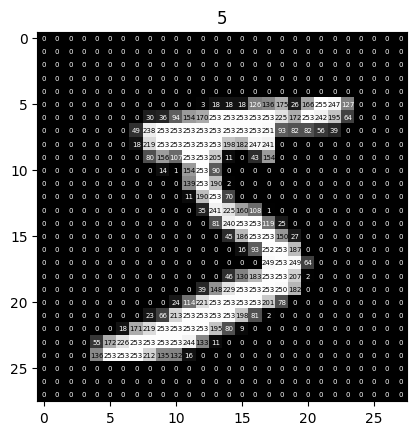

In [6]:
# 이미지 시각화를 위해 Matplotlib의 pyplot을 plt라는 이름으로 불러옵니다.
import matplotlib.pyplot as plt
# 전체 그림판 fig와 실제 그림 영역 ax를 생성합니다.
fig, ax = plt.subplots()
# 첫 번째 학습 이미지를 흑백으로 ax 영역에 표시합니다.
ax.imshow(train_data.data[0], cmap='gray')

# 첫 번째 이미지의 모든 세로 픽셀 위치를 반복합니다.
for i in range(train_data.data[0].shape[0]):
    # 현재 세로 위치에서 모든 가로 픽셀 위치를 반복합니다.
    for j in range(train_data.data[0].shape[1]):
        # 픽셀값이 128보다 작으면 흰 글자, 그렇지 않으면 검은 글자를 사용하도록 c를 정합니다.
        c = 1 if train_data.data[0][i, j].item() < 128 else 0
        # 현재 픽셀 위치에 픽셀값을 텍스트로 표시하고 색상·정렬·글자 크기를 지정합니다.
        ax.text(j, i, str(train_data.data[0][i, j].item()), color=(c, c, c), ha='center', va='center',fontsize=5)

# 첫 번째 이미지의 실제 정답 숫자를 그림 제목으로 표시합니다.
plt.title('%i' % train_data.targets[0])
# 완성된 이미지와 픽셀값을 화면에 출력합니다.
plt.show()

# 7단계. 무작위 이미지 25장 확인

학습 이미지 25장을 무작위로 선택해 5×5 형태로 출력하고, 각 이미지의 실제 정답 숫자를 확인합니다.


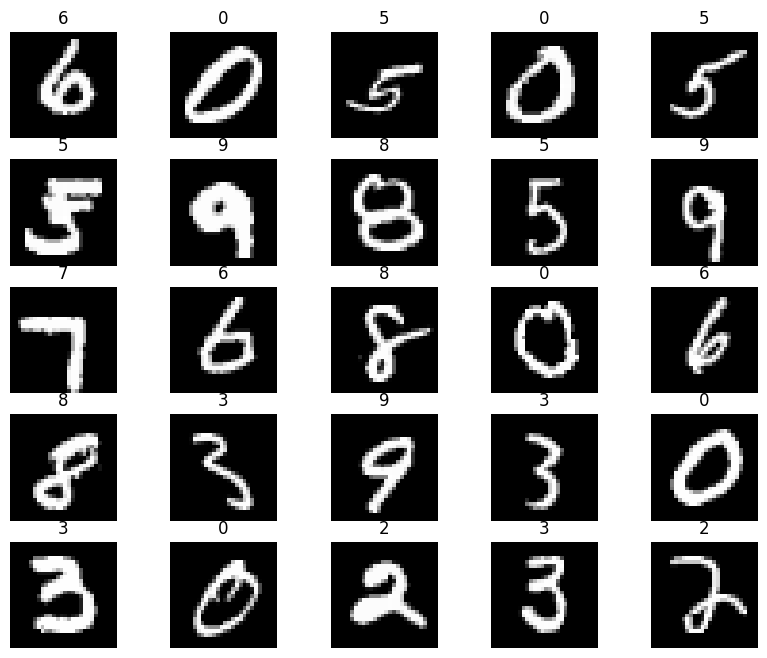

In [7]:
# 25개 이미지를 배치할 전체 그림판을 가로 10, 세로 8 크기로 만듭니다.
figure = plt.figure(figsize=(10, 8))
# 이미지를 5열 5행으로 배치하도록 열과 행 수를 정합니다.
cols, rows = 5, 5
# subplot 위치 번호 1부터 25까지 반복합니다.
for i in range(1, cols * rows + 1):
    # 학습 데이터 범위 안에서 무작위 이미지 인덱스 하나를 선택합니다.
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    # 선택한 위치의 이미지 Tensor와 실제 정답 라벨을 가져옵니다.
    img, label = train_data[sample_idx]
    # 5행 5열 중 현재 i번째 위치에 작은 그래프 영역을 추가합니다.
    figure.add_subplot(rows, cols, i)
    # 현재 이미지의 실제 정답 숫자를 제목으로 표시합니다.
    plt.title(label)
    # 축과 눈금을 숨깁니다.
    plt.axis("off")
    # 채널 차원을 제거한 이미지를 흑백으로 표시합니다.
    plt.imshow(img.squeeze(), cmap="gray")
# 25개 이미지가 배치된 그림을 화면에 출력합니다.
plt.show()

# 8단계. DataLoader 구성

전체 데이터를 100장씩 미니배치로 나누어 모델에 전달할 학습용·테스트용 DataLoader를 만듭니다.


In [8]:
# PyTorch의 DataLoader 클래스를 불러옵니다.
from torch.utils.data import DataLoader
# 학습용과 테스트용 DataLoader를 담을 딕셔너리를 시작합니다.
loaders = {
    # train 키에 학습용 DataLoader 생성을 시작하며 train_data를 전달합니다.
    'train' : torch.utils.data.DataLoader(train_data,
                                          # 한 번에 이미지 100장씩 묶습니다.
                                          batch_size=100,
                                          # 매 epoch마다 학습 데이터 순서를 무작위로 섞습니다.
                                          shuffle=True,
                                          # 데이터를 읽는 보조 프로세스를 1개 사용하고 학습 DataLoader 생성을 끝냅니다.
                                          num_workers=1),

    # test 키에 테스트용 DataLoader 생성을 시작하며 test_data를 전달합니다.
    'test'  : torch.utils.data.DataLoader(test_data,
                                          # 테스트 이미지도 한 번에 100장씩 묶습니다.
                                          batch_size=100,
                                          # 테스트 데이터 순서도 무작위로 섞습니다.
                                          shuffle=True,
                                          # 데이터를 읽는 보조 프로세스를 1개 사용하고 테스트 DataLoader 생성을 끝냅니다.
                                          num_workers=1),
# loaders 딕셔너리 정의를 끝냅니다.
}
# 생성된 loaders 딕셔너리를 노트북 화면에 출력합니다.
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x780f8b815fa0>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x780f882f0170>}

# 9단계. CNN 모델 정의

합성곱층 2개를 사용하는 CNN입니다.

`1×28×28 → 16×14×14 → 32×7×7 → 1568개 특징 → 숫자 10개 점수`

각 줄에서 입력·출력 채널, 필터 크기, 패딩, 풀링, 펼치기와 완전연결층을 설명합니다.


In [9]:
# CNN Model (2 conv layers) 클래스 선언
# CNN이라는 사용자 정의 신경망 클래스를 만들고 torch.nn.Module을 상속합니다.
class CNN(torch.nn.Module):

    # 모델 객체 생성 시 실행되는 초기화 함수를 정의합니다.
    def __init__(self):
        # 부모 클래스의 초기화 기능을 실행해 PyTorch가 층과 파라미터를 관리하게 합니다.
        super(CNN, self).__init__()
        # 첫 번째 합성곱 블록을 Sequential로 정의합니다.
        self.layer1 = torch.nn.Sequential(
            # 입력 1채널, 출력 16채널, 5×5 필터, stride 1, padding 2의 합성곱층입니다.
            torch.nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2),   # 28 x 28 ==> 32 x 32 ==> 28 x 28
            # 음수는 0으로 바꾸는 ReLU 활성화 함수를 적용합니다.
            torch.nn.ReLU(),
            # 2×2 최대 풀링으로 28×28을 14×14로 줄입니다.
            torch.nn.MaxPool2d(kernel_size=2, stride=2))                  # 28 x 28 ==> 14 x 14
        # 두 번째 합성곱 블록을 Sequential로 정의합니다.
        self.layer2 = torch.nn.Sequential(
            # 입력 16채널, 출력 32채널, 5×5 필터, stride 1, padding 2의 합성곱층입니다.
            torch.nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),   # 14 x 14 ==> 18 x 18 ==> 14 x 14
            # 두 번째 합성곱 결과에 ReLU를 적용합니다.
            torch.nn.ReLU(),
            # 2×2 최대 풀링으로 14×14를 7×7로 줄입니다.
            torch.nn.MaxPool2d(kernel_size=2, stride=2))                  # 14 x 14 ==> 7 x 7
        # 32×7×7=1568개 특징을 숫자 10개 점수로 바꾸는 완전연결층입니다.
        self.fc = torch.nn.Linear(32 * 7 * 7, 10, bias=True)
        # 완전연결층 가중치를 Xavier Uniform 방식으로 초기화합니다.
        torch.nn.init.xavier_uniform_(self.fc.weight)

    # 입력 데이터가 모델을 통과하는 순서를 정의하는 forward 함수를 시작합니다.
    def forward(self, x):
        # 입력 x를 첫 번째 합성곱 블록에 통과시킵니다.
        out = self.layer1(x)
        # 첫 번째 결과를 두 번째 합성곱 블록에 통과시킵니다.
        out = self.layer2(out)
        # 배치 크기는 유지하고 나머지 32×7×7 특징을 한 줄로 펼칩니다.
        out = out.view(out.size(0), -1)
        # 펼친 특징을 완전연결층에 넣어 숫자 10개 점수를 계산합니다.
        out = self.fc(out)
        # 최종 출력값을 반환합니다.
        return out

# 10단계. CNN 모델 객체 생성

앞에서 정의한 CNN 클래스를 실제 학습과 예측에 사용할 모델 객체로 생성합니다.


In [10]:
# CNN 클래스를 실제 모델 객체로 생성하여 model 변수에 저장합니다.
model = CNN()

# 11단계. 모델 구조 확인

생성된 모델에 포함된 합성곱층, 활성화 함수, 풀링층과 완전연결층을 출력합니다.


In [11]:
# model 객체를 출력하여 전체 CNN 구조를 확인합니다.
model

CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)

# 12단계. 학습 설정

학습률, 손실함수와 Adam 최적화 알고리즘을 설정합니다.


In [12]:
# optimizer가 가중치를 수정할 크기인 학습률을 0.01로 설정합니다.
learning_rate = 0.01
# 다중 클래스 분류용 CrossEntropyLoss 손실함수를 생성합니다.
loss_func = torch.nn.CrossEntropyLoss()
# 모델의 모든 파라미터를 Adam으로 업데이트하도록 optimizer를 생성합니다.
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# 13단계. Epoch 설정

전체 학습 데이터를 처음부터 끝까지 반복할 횟수를 10회로 설정합니다.


In [13]:
# 전체 학습 데이터를 처음부터 끝까지 반복할 횟수를 10으로 설정합니다.
training_epochs = 10

# 14단계. 모델 학습

미니배치마다 gradient 초기화, 예측, 손실 계산, 역전파와 가중치 업데이트를 반복합니다.


In [14]:
# train my model
# 학습용 DataLoader의 전체 미니배치 개수를 계산합니다.
total_batch = len(loaders['train'])
# 설정한 epoch 수만큼 전체 학습을 반복합니다.
for epoch in range(training_epochs):
    # 현재 epoch의 평균 손실을 누적할 값을 0으로 초기화합니다.
    avg_cost = 0

    # 학습 DataLoader에서 이미지 배치 X와 정답 배치 Y를 가져옵니다.
    for X, Y in loaders['train']:
        # 이전 배치에서 남은 gradient를 0으로 초기화합니다.
        optimizer.zero_grad()             # gradient clear before computing new gradient for the new batch
        # 이미지 배치 X를 모델에 넣어 숫자 10개 점수를 예측합니다.
        pred = model(X)
        # 예측값 pred와 실제 정답 Y의 차이를 손실로 계산합니다.
        cost = loss_func(pred, Y)
        # 손실을 기준으로 역전파하여 각 파라미터의 gradient를 계산합니다.
        cost.backward()
        # Adam optimizer가 gradient를 이용해 모델 파라미터를 업데이트합니다.
        optimizer.step()

        # 현재 배치 손실을 전체 배치 수로 나누어 평균 손실에 누적합니다.
        avg_cost += cost / total_batch

    # 현재 epoch 번호와 평균 손실을 형식에 맞춰 출력합니다.
    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, avg_cost))

# 모든 epoch 학습이 끝났다는 문장을 출력합니다.
print('Learning Finished!')

[Epoch:    1] cost = 0.142763898
[Epoch:    2] cost = 0.0566466674
[Epoch:    3] cost = 0.0501382463
[Epoch:    4] cost = 0.0446396321
[Epoch:    5] cost = 0.0413799398
[Epoch:    6] cost = 0.0389188044
[Epoch:    7] cost = 0.0394670218
[Epoch:    8] cost = 0.0365958959
[Epoch:    9] cost = 0.0340655856
[Epoch:   10] cost = 0.0380570292
Learning Finished!


# 15단계. 테스트 이미지 예측

테스트 이미지 25장을 무작위로 골라 모델이 예측한 숫자를 이미지 위에 표시합니다.


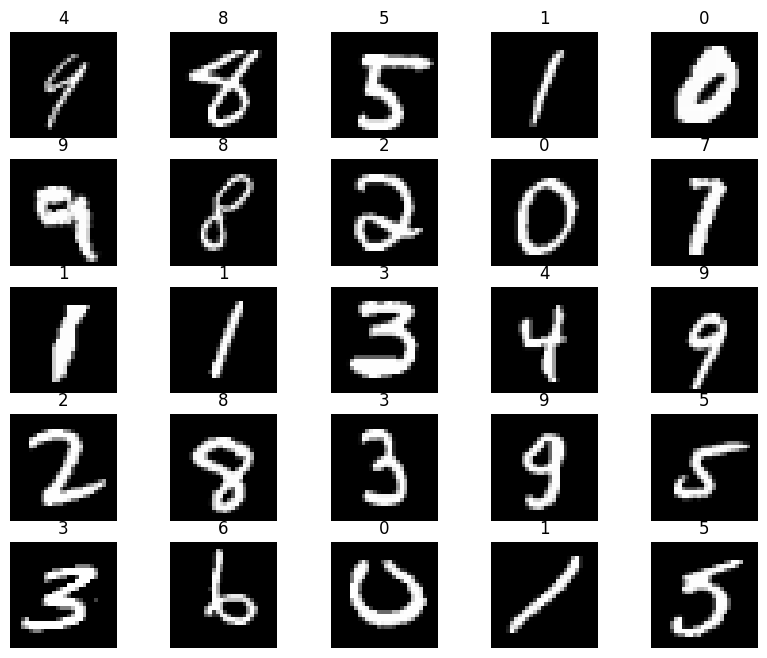

In [15]:
# 모델을 학습 모드에서 평가 모드로 전환합니다.
model.eval()
# 테스트 이미지 25장을 배치할 전체 그림판을 만듭니다.
figure = plt.figure(figsize=(10, 8))
# 이미지를 5열 5행으로 배치하도록 설정합니다.
cols, rows = 5, 5
# subplot 위치 번호 1부터 25까지 반복합니다.
for i in range(1, cols * rows + 1):
    # 테스트 데이터 범위에서 무작위 이미지 인덱스 하나를 선택합니다.
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    # 이미지에 배치 차원을 추가해 모델에 넣고 숫자 10개 점수를 계산합니다.
    test_output = model(torch.unsqueeze(loaders['test'].dataset[sample_idx][0],dim=0))
    # 가장 큰 점수의 위치를 최종 예측 숫자로 선택합니다.
    label = torch.argmax(test_output)
    # 5행 5열 중 현재 위치에 작은 그래프 영역을 추가합니다.
    figure.add_subplot(rows, cols, i)
    # 예측 숫자를 이미지 제목으로 표시합니다.
    plt.title(label.numpy())
    # 축과 눈금을 숨깁니다.
    plt.axis("off")
    # 테스트 이미지를 NumPy 배열로 바꾸어 흑백으로 표시합니다.
    plt.imshow(loaders['test'].dataset[sample_idx][0].squeeze().detach().numpy(), cmap="gray")
# 25개 테스트 이미지와 예측 숫자를 화면에 출력합니다.
plt.show()